# Method Analysis

* VNeo method parsing adapted from from https://github.com/nickdelgrosso/XCaliburMethodReader/tree/master

## Imports

In [1]:
# import olefile
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re
import seaborn as sns
import os
import sys

%matplotlib inline

In [2]:
import scanpy as sc

In [73]:
%load_ext autoreload
%autoreload 2

# Add parent directory to path to import modules from code/
sys.path.insert(0, os.path.abspath('..'))

from vneo_method import VNeoMethod
from lc_method_collection import VNeoMethodCollection
from ms_method import MicroTOFMethod
from ms_method_collection import MSMethodCollection
from anndiannloader import DiannLoader as dl
from diann_collection import DiannCollection
from filters import filter_mask
from method_mapper import map_lcms_methods

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Base

In [4]:
source = 'base'

In [5]:
if source == 'base':
    base = '/hpc/projects/mass_spec/eileenwang/'

## Load LC Methods

#### LC Collection Object

In [74]:
lccollection = VNeoMethodCollection()

In [75]:
lccollection.add_methods_from_folder(f'{base}MethodOpt/LCMSmethodAnalysis/SampleData/methods/LC')

/hpc/projects/mass_spec/eileenwang/MethodOpt/LCMSmethodAnalysis/code/vneo_method.py:127: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  gradient_df[col] = pd.to_numeric(gradient_df[col], errors='ignore')
/hpc/projects/mass_spec/eileenwang/MethodOpt/LCMSmethodAnalysis/code/vneo_method.py:130: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  equil_df[col] = pd.to_numeric(equil_df[col], errors='ignore')


In [5]:
# lc_methods = '\n'.join(lccollection.methods.keys())
# print(f'Methods loaded: {len(lccollection.methods.keys())}\n{lc_methods}')

<Axes: title={'center': 'Gradient Comparison: 17p5m150nlv13, 23p75m150nlv16, 24m150nlThermo, 20m150nlv15, 20m150nlML30mA15v2, 36m150nlLong40, 18p6m200nlv28drop, 17p75m150nlv12, 23m150nlv21Zebra, 10m150nlRainmanA15-75, 11p5m150nlv9, 20m150nlML30mA15phospho4, 25m200nlv5, 20m150nlML23p5mA15v1, 20p5m150nlv14, 23p65m150nlv18Zebra, 25m150nlv5, 27m150nlv3, 19m200nlv26, 25m200nlv24, 19m200nlv25, 25m200nlv23, 19m200nlv27PC2drop, 16m150nlv8, 18p5m200nlv29, 20p5m150nlv6, 17p5m150nlv10, 18p6m200nlv30, 25m150nlv4, 25p15m150nlv22Zebra, 36m150nlSlow40, 23p65m150nlv19Zebra, 20p5m150nlv7, 25p15m150nlv20Zebra, 17p7m150nlv11, 23p75mHighACNWash150nlv17'}, xlabel='time [min]', ylabel='Value [%]'>

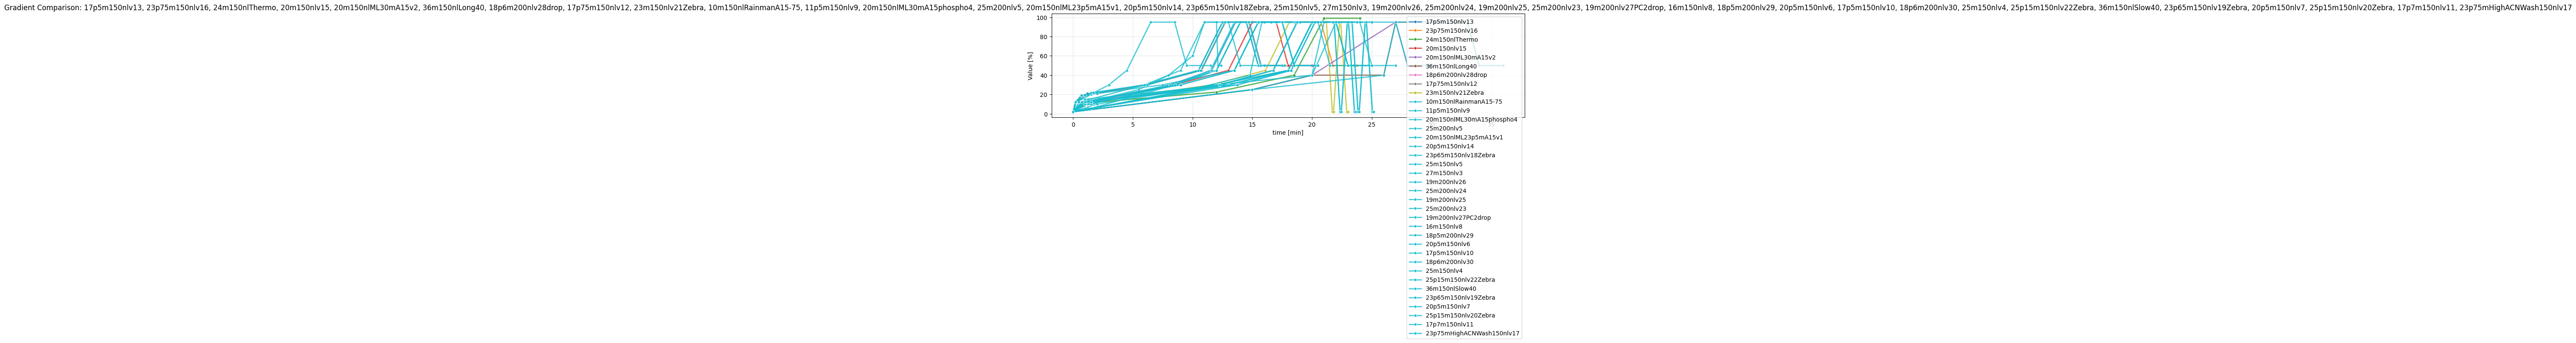

In [7]:
lccollection.plot_gradients(
                        x_col = 'time [min]',
                        y_cols = ['Neo.PumpModule.Pump.%B.Value [%]'], 
                        twin_axes=True , 
                        markers=True
)

## MS Methods

### Load MS Methods

In [8]:
# Intialize MS method collector object
mscollection = MSMethodCollection()

In [9]:
# # Method 1: Add single method with explicit name
# collection.add_method("/Users/eileen.wang/Desktop/diann/SampleData/methods/MS/DIA003.proteoscape.m")

# Method 2: Add from zip file (extracts and adds all methods inside)
mscollection.add_methods_from_folder(f"{base}MethodOpt/LCMSmethodAnalysis/SampleData/methods/MS/260130_11AM.zip")
# collection.add_methods_from_paths(["/Users/eileen.wang/Desktop/diann/SampleData/methods/MS/DIA003.proteoscape.m"], overwrite = 'ignore')
msmethod_names = '\n'.join(mscollection.methods.keys())
# print(f"Loaded {len(mscollection)} methods: {msmethod_names}")


### MS Meth Summary

In [849]:
# mscollection.summary_df()

### Find Differences between methods

In [954]:
method = mscollection['DIA011RT70expandedrange.proteoscape']
value = method['Collision_GasSupply_Set']  # Direct access!
# cap_voltage = method['default_Source_CapillarySetValue']  # Positive only
windows = method['dia_windows']  # Direct access!


In [964]:
df = mscollection.to_dataframe(
    method_names=['DIA007.proteoscape', 'DIA016.proteoscape'],  # Optional: subset methods
    # param_names=['Collision_GasSupply_Set', 'dia_window_count'],  # Optional: subset params
    exclude_dia_windows=True  # Exclude DataFrame objects by default
)

In [31]:
df = mscollection.to_dataframe()

In [49]:
## MS mass start/end
# df[['Mode_ScanBegin', 'Mode_ScanEnd']]

In [966]:
# finding differences between 2+ methods
diff = mscollection.find_differences(['DIA011RT60.proteoscape','DIA018.proteoscape'])
diff

,Parameter,Type,Description,DIA011RT60.proteoscape,DIA018.proteoscape
0,Vacuum_LastCapillaryCleaningDate,instrument_param,,2025-11-24T12:05:17-08:00,2025-08-18T09:57:05-07:00
1,TOF_DetectorTofSetValue,instrument_param,,2265.0,2252.0
2,default_IMS_Calibration_RampVelocity_Save,polarity_param,positive polarity,0.205078,0.427318
3,default_IMS_Calibration_LastCalibrationDate,polarity_param,positive polarity,2025-09-10T17:35:19-07:00,2025-09-11T11:46:42-07:00
4,default_IMS_CalibrationRampEnd,polarity_param,positive polarity,139.972162,140.502687
5,default_IMS_Calibration_LastCalibrationMassInt...,polarity_param,positive polarity,"[1445930.0230822468, 1471710.2676116882, 75735...","[787028.996186168, 1230470.924191452, 177976.4..."
6,default_IMS_Calibration_Funnel1In_Pressure,polarity_param,positive polarity,2.387,2.403
7,default_IMS_CalibrationCoefficients,polarity_param,positive polarity,"[0.03084927968991898, 160.35509090775577, 15.9...","[0.001523152265349233, 165.08327143248422, 16...."
8,default_IMS_CalibrationRampStart,polarity_param,positive polarity,243.402636,239.900581
9,default_IMS_Calibration_StdDev,polarity_param,positive polarity,0.000138,0.000599


#### Plotting differences

No numeric parameters found to plot


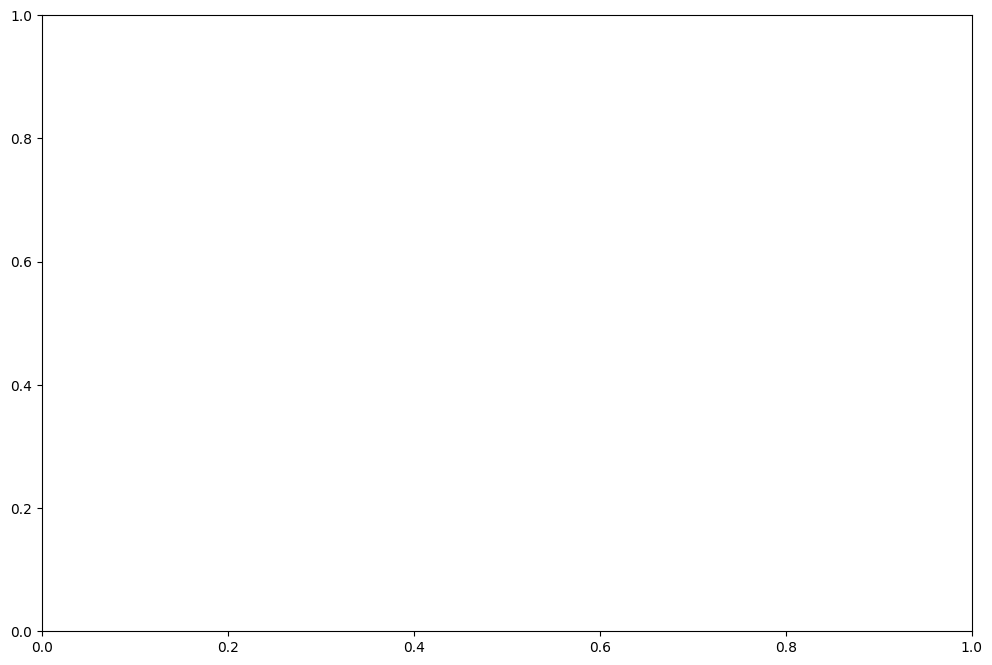

In [10]:
mscollection.plot_differences(method_names = ['DIA011RT60.proteoscape',
'DIA018.proteoscape',
'DIA011RT60.proteoscape',
'DIA018.proteoscape',
'DIA011QC2v1600.proteoscape'],
)

### Plot DIA Windows

<Axes: title={'center': 'DIA Windows Overlay: DIA011RT60.proteoscape, DIA018.proteoscape'}, xlabel='m/z', ylabel='1/K0 (Ion Mobility)'>

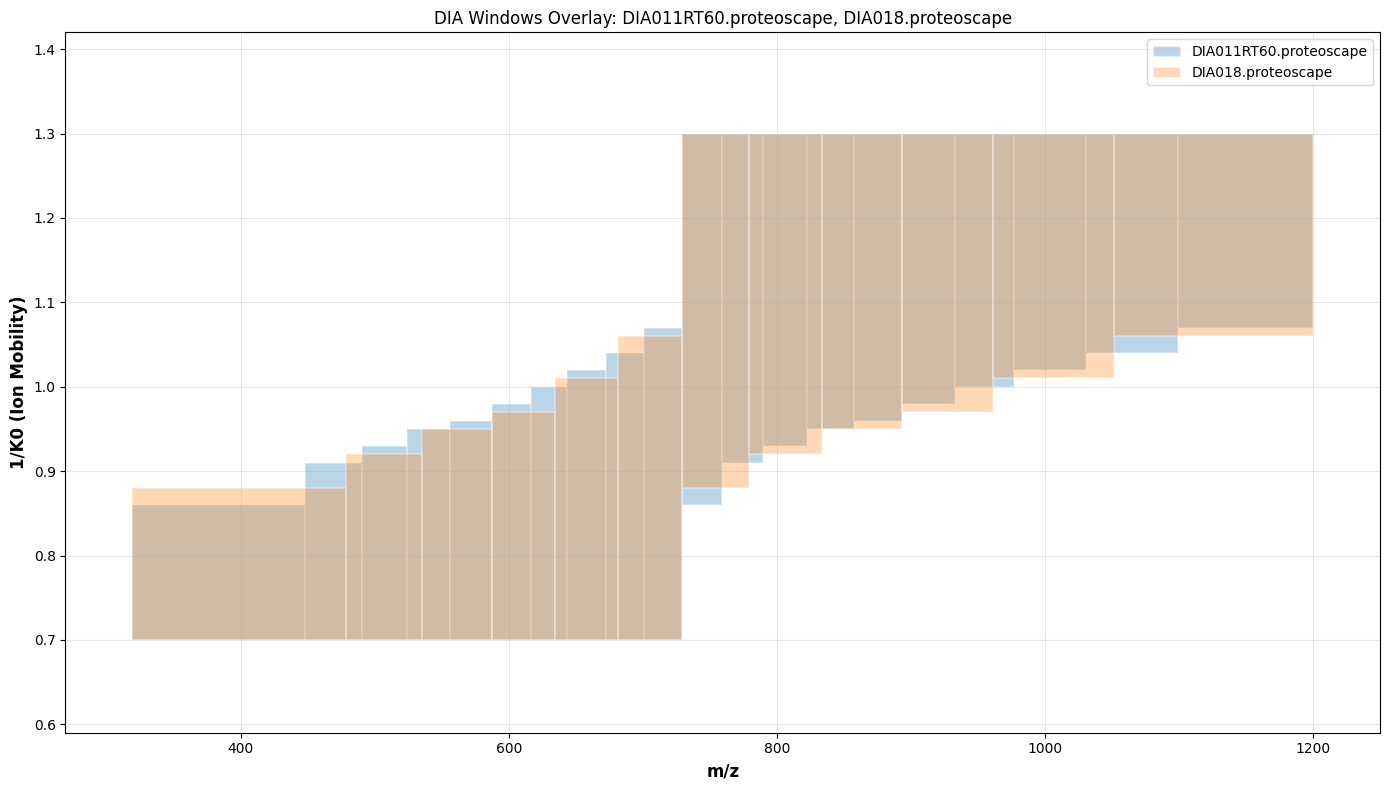

In [902]:
mscollection.plot_windows(['DIA011RT60.proteoscape', 'DIA018.proteoscape'], color_by_method=True,
                    alpha=0.3,
                    # edge_color='white',
                    # figsize=(14, 8),
                    show_labels=False)

## Loading Searches

### BPS

In [ ]:
# bpscollection = DiannCollection(log_file = f'{base}/MethodOpt/outputs/bpscollection.log')

In [ ]:
# for i in ['5bb65d07aa6a2f77f81b5e08ab034d2b', 
#           '91e1fd4b7eb0d9bcc1efe2d697ec6237',
#           '4032c8c9eb896d865ede0acf6854adbd',
#           'e086878c8a63cdb635efbfdfc701b60b'
#          ]:

#     bpscollection.add_from_folder(f"{base}/MethodOpt/LCMSmethodAnalysis/SampleData/BPS/{i}.zip", levels=["precursor", "protein"])

In [ ]:
# bpscollection.save(f'{base}/MethodOpt/outputs/bpscollection.pkl')

Saved collection to /hpc/projects/mass_spec/eileenwang/MethodOpt/outputs/bpscollection.pkl


In [9]:
bpscollection = DiannCollection.from_file(f'{base}/MethodOpt/outputs/bpscollection.pkl')
## saved obs are nan except for precusor id only for precusor

Loaded collection from /hpc/projects/mass_spec/eileenwang/MethodOpt/outputs/bpscollection.pkl


### Fragpipe

In [ ]:
# fpcollection = DiannCollection(log_file = f'{base}/MethodOpt/outputs/fpcollection.log')

In [ ]:
# fpcollection.add_single_search(f"{base}/LIPR/timsTOF_VNeo_100pg/FP_100pg20ng_25m/diann-output/report.tsv", search_type='fragpipe', levels=['precursor', 'protein'])

In [ ]:
# fpcollection.save(f'{base}/MethodOpt/outputs/fpcollection.pkl')

Saved collection to /hpc/projects/mass_spec/eileenwang/MethodOpt/outputs/fpcollection.pkl


In [10]:
fpcollection = DiannCollection.from_file(f'{base}/MethodOpt/outputs/fpcollection.pkl')

Loaded collection from /hpc/projects/mass_spec/eileenwang/MethodOpt/outputs/fpcollection.pkl


In [ ]:
# Summary
# # summary = collection.summary_df()
# # print(summary)

### Combine Sample and Method

In [ ]:
# map_lcms_methods(bpscollection, '/hpc/projects/mass_spec/eileenwang/MethodOpt/LCMSmethodAnalysis/SampleData/Sequences/2026_01_lcmsmethodmapping.csv')
# map_lcms_methods(fpcollection, '/hpc/projects/mass_spec/eileenwang/MethodOpt/LCMSmethodAnalysis/SampleData/Sequences/2026_01_lcmsmethodmapping.csv')

### Filtering

In [35]:
bpscollection.data['precursor'].to_df('Precursor.Quantity').melt(value_name='sample')

,File.Name,sample
0,Blank_2ACN01TFA_0015DDM_2uL_VNeo_Aurora15_16_2...,NaN
1,Blank_2ACN01TFA_0015DDM_2uL_VNeo_Aurora15_16_2...,NaN
2,Blank_2ACN01TFA_0015DDM_2uL_VNeo_Aurora15_16_2...,NaN
3,Blank_2ACN01TFA_0015DDM_2uL_VNeo_Aurora15_16_2...,NaN
4,Blank_2ACN01TFA_0015DDM_2uL_VNeo_Aurora15_16_2...,NaN
...,...,...
9077739,HeLa_50ng_2ACN01TFA_0015DDM_2uL_VNeo_Aurora15_...,NaN
9077740,HeLa_50ng_2ACN01TFA_0015DDM_2uL_VNeo_Aurora15_...,NaN
9077741,HeLa_50ng_2ACN01TFA_0015DDM_2uL_VNeo_Aurora15_...,10855.0
9077742,HeLa_50ng_2ACN01TFA_0015DDM_2uL_VNeo_Aurora15_...,78925.0


In [42]:
def check_dist(ad, layer, samples=None, figsize=(10,6)):
    fig, ax = plt.subplots(figsize=figsize)
    df = ad.to_df(layer)
    if samples:
        df = df.loc[:, samples]

    df = df.melt(value_name=layer)

    for s in df.columns:
        sns.violinplot(data = df, x = 'File.Name', y = layer, ax=ax)
    
    plt.xticks(rotation=90)

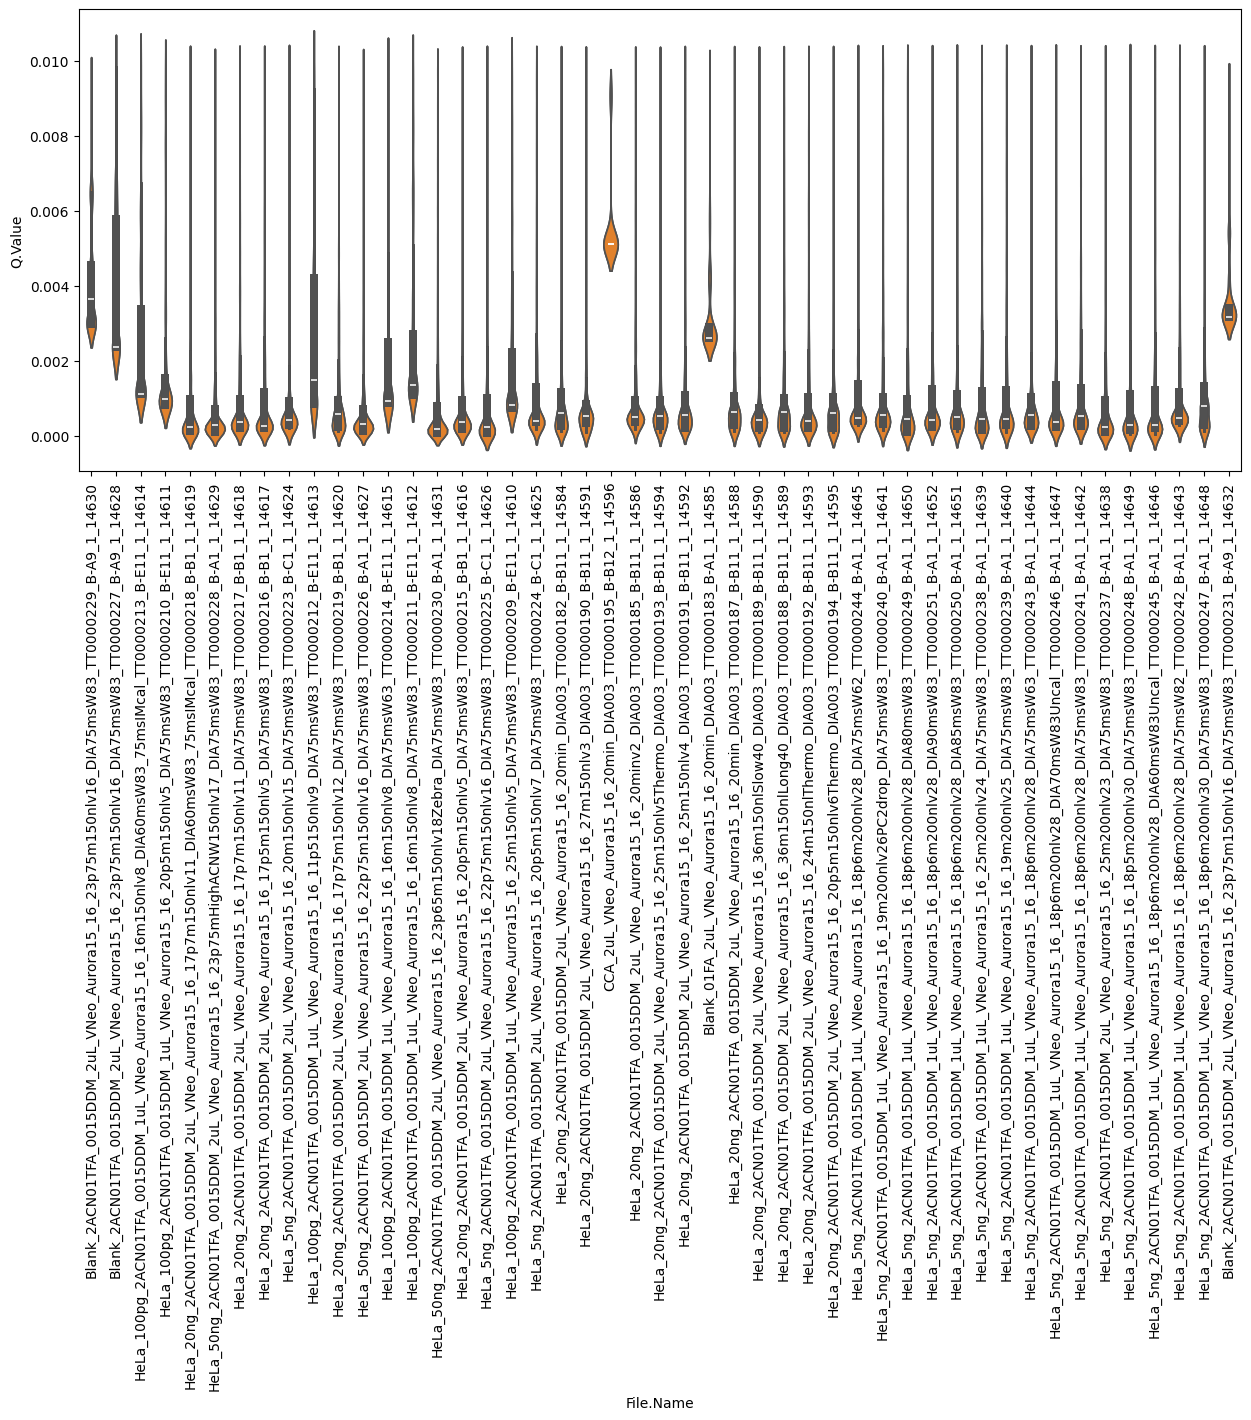

In [44]:
check_dist(bpscollection.data['precursor'], 'Q.Value', figsize=(15,6))

In [46]:
test = bpscollection.data['precursor'].copy()

/hpc/mydata/eileen.wang/anaconda/25.3.1/x86_64/envs/methodanalysis/lib/python3.11/site-packages/anndata/_core/anndata.py:1813: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [26]:
test.layers['Q.Value'] < 0.01

array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False,  True],
       [False, False, False, ..., False, False,  True],
       [False, False, False, ..., False, False,  True]],
      shape=(174572, 52))

In [ ]:
lowflow = test2[:, test2.var['hystar_index'].isin(['14616'])].layers['Precursor.Quantity'].flatten()

highflow = test2[:, test2.var['hystar_index'].isin(['14617'])].layers['Precursor.Quantity'].flatten()

* *are RT being shifted in the flow drop or are we losing peptides?
* how are they being shifted? earlier or later?

<Axes: xlabel='HeLa_20ng_2ACN01TFA_0015DDM_2uL_VNeo_Aurora15_16_17p5m150nlv5_DIA75msW83_TT0000216_B-B1_1_14617', ylabel='Count'>

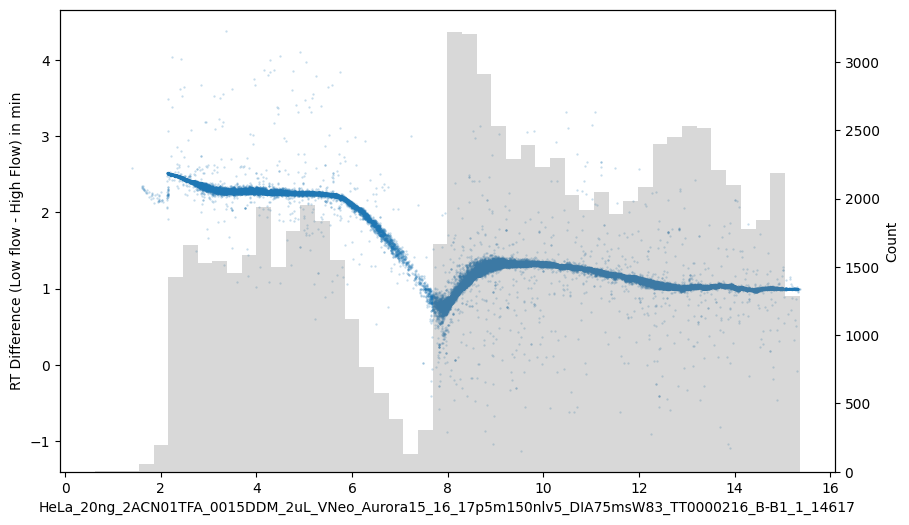

In [105]:
fig, ax = plt.subplots(figsize=(10,6))
ax2 = ax.twinx()
sns.scatterplot(x = test4['HeLa_20ng_2ACN01TFA_0015DDM_2uL_VNeo_Aurora15_16_17p5m150nlv5_DIA75msW83_TT0000216_B-B1_1_14617'],
                y= test4['HeLa_20ng_2ACN01TFA_0015DDM_2uL_VNeo_Aurora15_16_20p5m150nlv5_DIA75msW83_TT0000215_B-B1_1_14616'] - test4['HeLa_20ng_2ACN01TFA_0015DDM_2uL_VNeo_Aurora15_16_17p5m150nlv5_DIA75msW83_TT0000216_B-B1_1_14617'] - 2,
                s=2,
                alpha=0.25,
                edgecolor=None,
                ax=ax)
ax.set_ylabel('RT Difference (Low flow - High Flow) in min')
sns.histplot(test4['HeLa_20ng_2ACN01TFA_0015DDM_2uL_VNeo_Aurora15_16_17p5m150nlv5_DIA75msW83_TT0000216_B-B1_1_14617'] , ax=ax2, alpha=0.3, edgecolor=None, color='grey')

<Axes: >

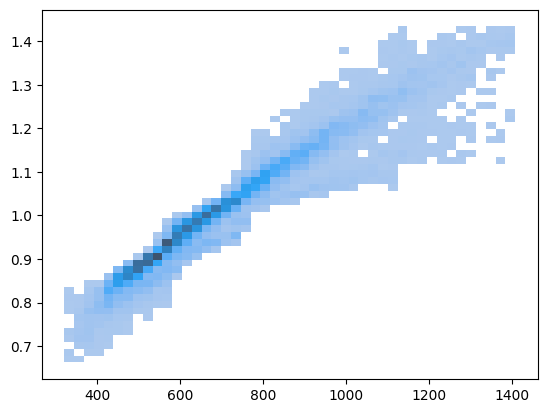

In [47]:
sns.histplot(x=test3.layers['Precursor.Calibrated.Mz'].flatten(), 
             y= test3.layers['Exp.1/K0'].flatten())

<Axes: ylabel='Count'>

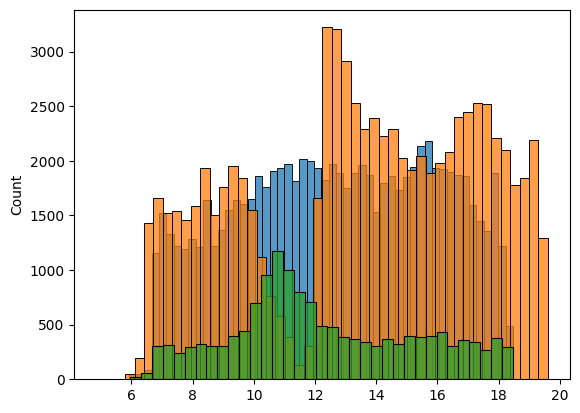

In [64]:
sns.histplot(test2[:, test2.var['hystar_index'].isin(['14616'])].layers['RT'].flatten())
sns.histplot(test2[:, test2.var['hystar_index'].isin(['14617'])].layers['RT'].flatten() + 4.25)

sns.histplot(test3.layers['RT'].flatten()) 

In [ ]:
def get_sample(ad, obs=None, var={None}):
    for obs 

In [ ]:
def get_sample_value(ad, )

<Axes: ylabel='Count'>

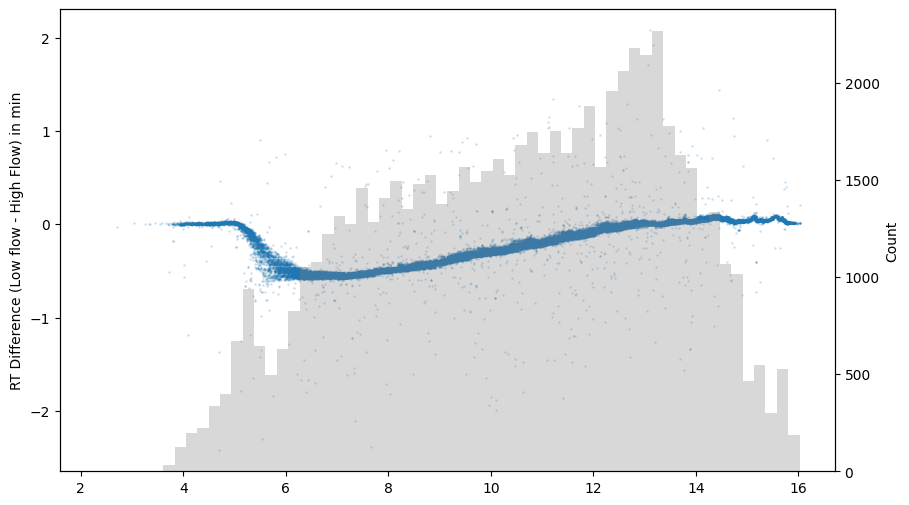

In [62]:
fig, ax = plt.subplots(figsize=(10,6))
ax2 = ax.twinx()
sns.scatterplot(x = test[:, test.var['hystar_index'].isin(['14648'])].layers['RT'].flatten(),
                y= test[:, test.var['hystar_index'].isin(['14648'])].layers['RT'].flatten() - test[:, test.var['hystar_index'].isin(['14642'])].layers['RT'].flatten(),
                s=2,
                alpha=0.25,
                edgecolor=None,
                ax=ax)
ax.set_ylabel('RT Difference (Low flow - High Flow) in min')
sns.histplot(test[:, test.var['hystar_index'].isin(['14648'])].layers['RT'].flatten(), ax=ax2, alpha=0.3, edgecolor=None, color='grey')

In [125]:
def elution_param(lccollection, samplecollection, sample, dead_volume=None):
  # How much volume is pushed through the column at the RT of the first peptide that elutes
  # Essentially dead volume of the LC system

  ad = samplecollection.data['precursor'].copy()
  
  lcmethod = ad.var.loc[sample, 'lc meth']

  gradient = lccollection.get_method(lcmethod).gradient.copy()
  gradient['volume (nL)'] = np.interp(gradient['time [min]'], gradient['time [min]'], gradient['time [min]'] * gradient['Neo.PumpModule.Pump.Flow.Nominal [µl/min]']) * 1000  # convert to nL
  gradient['total volume (nL)'] = gradient['volume (nL)'].cumsum()

  min_rt = np.nanmin(ad[:, ad.var_names == sample].layers['RT'])

  if not dead_volume:
    dead_volume = np.interp(min_rt, gradient['time [min]'], gradient['total volume (nL)'])
  print(f"Total volume passed at rt_min ({min_rt:.2f} min): {dead_volume:.2f} nL")

  print(np.interp(min_rt, gradient['time [min]'], gradient['total volume (nL)']))

  # # Assuming that it actually takes a a certain %B to go from the pumps to the end of the column, assuming no deadvolume
  # meth['Nominal Time to %B'] = (meth['Time (min)'] + total_volume_at_rt_min / meth['Flow (nL/min)'])

  # How much volume passes through the system for elution, assuming no dead volume


  # total solvent volume that passes through the system including dead volume
  gradient['Total + Dead Volume (nL)'] = gradient['total volume (nL)'] + dead_volume
  # time it actually takes to elute the set %B through the end of the column, including dead volume
  gradient['Actual Time to Elute Nominal %B (min)'] = gradient['Total + Dead Volume (nL)'].apply(lambda x: np.interp(x, gradient['total volume (nL)'], gradient['time [min]']))

  gradient['Actual %B'] = gradient['time [min]'].apply(lambda x: np.interp(x, gradient['Actual Time to Elute Nominal %B (min)'], gradient['Neo.PumpModule.Pump.%B.Value [%]']))

#   df['Nominal Elution Volume (nL)'] = np.interp(df['Rt'], gradient['Time (min)'], gradient['Total Volume (nL)'])
#   # What %B a peptide theoretically elutes at assuming no dead volume
#   df['Nominal Elution %B'] = np.interp(df['Rt'], gradient['Time (min)'], gradient['%B'])

#   # What %B a peptide actually elutes at by subtracting the amount of time it takes for everything to pass through the system + column
#   ## hmm should this actually only take into account the column volume? not the fully system volume?
#   df['Actual Elution %B'] = np.interp(df['Rt'], gradient['Time (min)'], gradient['Actual %B'])

  return gradient

In [112]:
np.nanmin(bpscollection['precursor'][:, bpscollection['precursor'].var_names == 'HeLa_5ng_2ACN01TFA_0015DDM_1uL_VNeo_Aurora15_16_18p6m200nlv30_DIA75msW83_TT0000247_B-A1_1_14648'].layers['RT'])

array(2.27879715)

In [126]:
df = elution_param(lccollection, bpscollection, 'HeLa_5ng_2ACN01TFA_0015DDM_1uL_VNeo_Aurora15_16_18p6m200nlv30_DIA75msW83_TT0000247_B-A1_1_14648')

Total volume passed at rt_min (2.28 min): 1142.81 nL
1142.8073404285715


/hpc/mydata/eileen.wang/anaconda/25.3.1/x86_64/envs/methodanalysis/lib/python3.11/site-packages/anndata/_core/anndata.py:1813: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [127]:
df

,time [min],Neo.PumpModule.Pump.Flow.Nominal [µl/min],Neo.PumpModule.Pump.%B.Value [%],Neo.PumpModule.Pump.Curve,volume (nL),total volume (nL),Total + Dead Volume (nL),Actual Time to Elute Nominal %B (min),Actual %B
0,0.0,0.65,2.0,5,0.0,0.0,1142.80734,2.278797,2.000000
1,1.0,0.65,10.0,5,650.0,650.0,1792.80734,5.087439,2.000000
2,1.1,0.20,12.0,5,220.0,870.0,2012.80734,6.038056,2.000000
3,8.1,0.20,30.0,5,1620.0,2490.0,3632.80734,9.824063,21.803202
4,11.6,0.20,45.0,5,2320.0,4810.0,5952.80734,12.440300,40.182205
5,13.6,0.20,95.0,5,2720.0,7530.0,8672.80734,14.332569,75.643114
6,15.6,0.20,95.0,5,3120.0,10650.0,11792.80734,15.668844,95.000000
7,16.6,1.00,95.0,5,16600.0,27250.0,28392.80734,16.722883,95.000000
8,18.6,1.00,95.0,5,18600.0,45850.0,46992.80734,18.600000,95.000000


<Axes: title={'center': 'Gradient Comparison: 18p6m200nlv30'}, xlabel='time [min]', ylabel='Value [%]'>

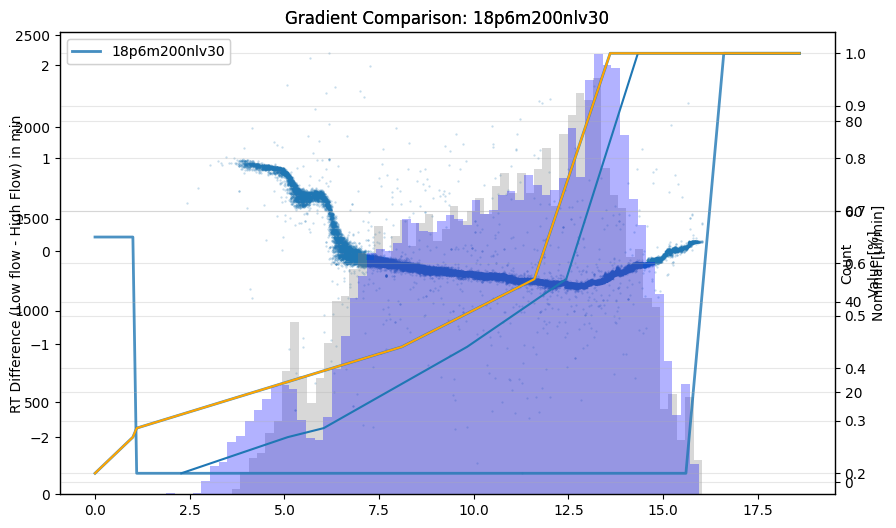

In [130]:
fig, ax = plt.subplots(figsize=(10,6))
ax2 = ax.twinx()
ax3 = ax.twinx()
ax4 = ax2.twinx()
sns.scatterplot(x = test[:, test.var['hystar_index'].isin(['14648'])].layers['RT'].flatten(),
                y= test[:, test.var['hystar_index'].isin(['14648'])].layers['RT'].flatten() - test[:, test.var['hystar_index'].isin(['14649'])].layers['RT'].flatten(),
                s=2,
                alpha=0.25,
                edgecolor=None,
                ax=ax)
ax.set_ylabel('RT Difference (Low flow - High Flow) in min')
sns.histplot(test[:, test.var['hystar_index'].isin(['14648'])].layers['RT'].flatten(), ax=ax2, alpha=0.3, edgecolor=None, color='grey')
sns.histplot(test[:, test.var['hystar_index'].isin(['14649'])].layers['RT'].flatten(), ax=ax2, alpha=0.3, edgecolor=None, color='blue')


lccollection.plot_gradients(['18p6m200nlv30'], y_cols = ['Neo.PumpModule.Pump.Flow.Nominal [µl/min]'], ax = ax3)
lccollection.plot_gradients(['18p6m200nlv30'], y_cols = ['Neo.PumpModule.Pump.%B.Value [%]'], ax = ax4)

sns.lineplot(data = df, x = 'Actual Time to Elute Nominal %B (min)', y='Neo.PumpModule.Pump.%B.Value [%]', ax=ax4, markers='o')
sns.lineplot(data = df, x = 'time [min]', y='Neo.PumpModule.Pump.%B.Value [%]', ax=ax4, color='orange', markers='o')

<Axes: ylabel='Count'>

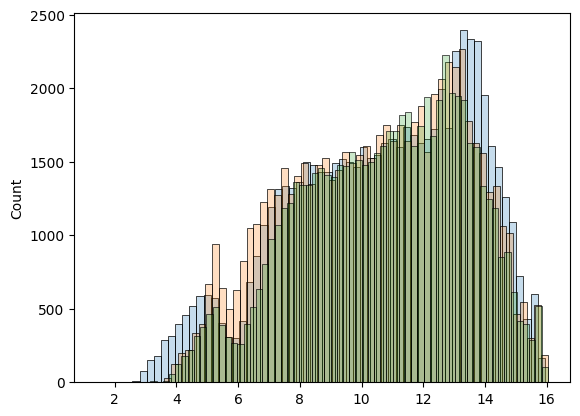

In [131]:
# 14649, 14648, 14642

sns.histplot(test[:, test.var['hystar_index'].isin(['14649'])].layers['RT'].flatten(), alpha=0.25)
sns.histplot(test[:, test.var['hystar_index'].isin(['14648'])].layers['RT'].flatten(), alpha=0.25)
sns.histplot(test[:, test.var['hystar_index'].isin(['14642'])].layers['RT'].flatten(), alpha=0.25)
# 14638

In [20]:
test2 = test[:, test.var['hystar_index'].isin(['14616', '14617'])]

In [16]:
test = fpcollection.data['precursor'].copy()

In [17]:
sc.pp.filter_cells(test, min_genes=0) # number of samples in which a given feature is quantified, based on X
sc.pp.filter_genes(test, min_cells=0) # number of features quantified in a given sample, based on X

In [ ]:
filter_mask(test, 
            filter_name = 'mask', 
            strict=False, 
            layer_threshold={'Q.Value': (0.01, 'max'),
                             'Lib.Q.Value': (0.01, 'max'), 
                             'Precursor.Quantity': (0, 'min')})

### Plotting

<Axes: title={'center': 'Gradient Comparison: 25m200nlv24, 18p6m200nlv28drop'}, xlabel='time [min]', ylabel='Nominal [µl/min]'>

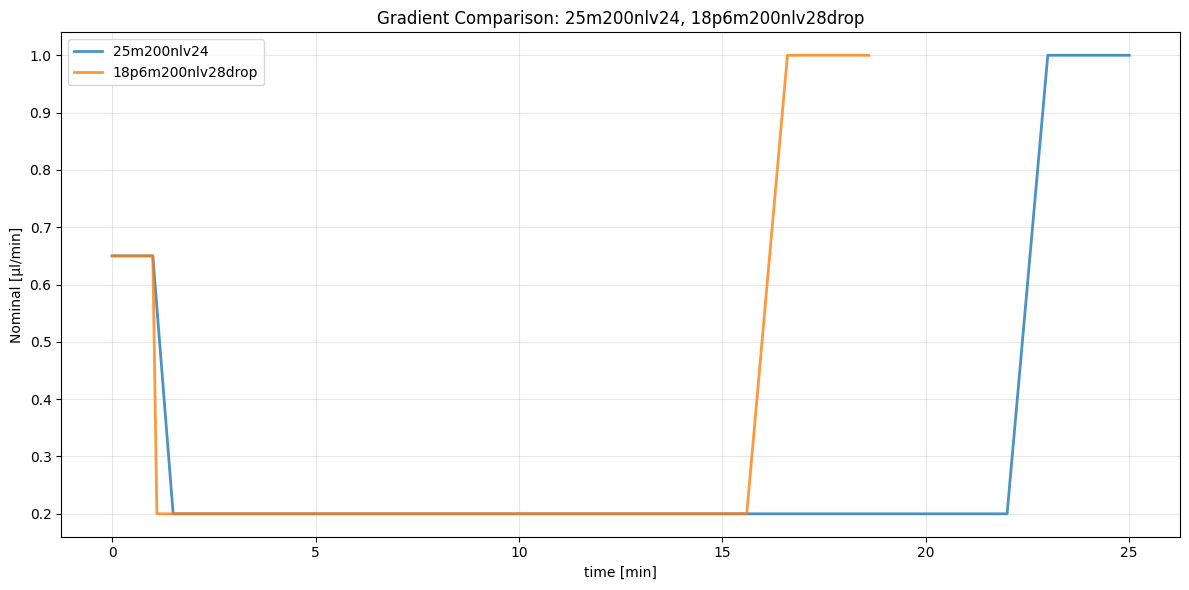

In [78]:
 lccollection.plot_gradients(['25m200nlv24', '18p6m200nlv28drop'], y_cols = ['Neo.PumpModule.Pump.Flow.Nominal [µl/min]'])

<Axes: title={'center': 'Gradient Comparison: 25m200nlv24, 25m200nlv23, 23p75m150nlv16'}, xlabel='time [min]', ylabel='Nominal [µl/min]'>

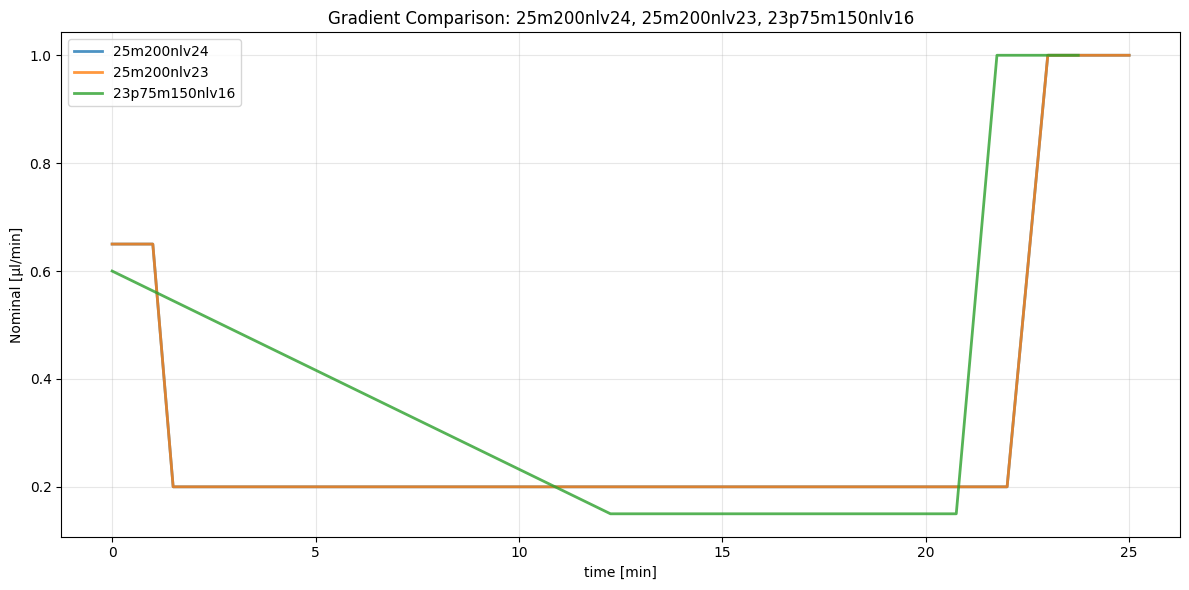

In [84]:
 lccollection.plot_gradients(['25m200nlv24', '25m200nlv23', '23p75m150nlv16'], y_cols = ['Neo.PumpModule.Pump.Flow.Nominal [µl/min]'])

<Axes: title={'center': 'Gradient Comparison: 25m200nlv24, 18p6m200nlv28drop, 25m200nlv23'}, xlabel='time [min]', ylabel='Value [%]'>

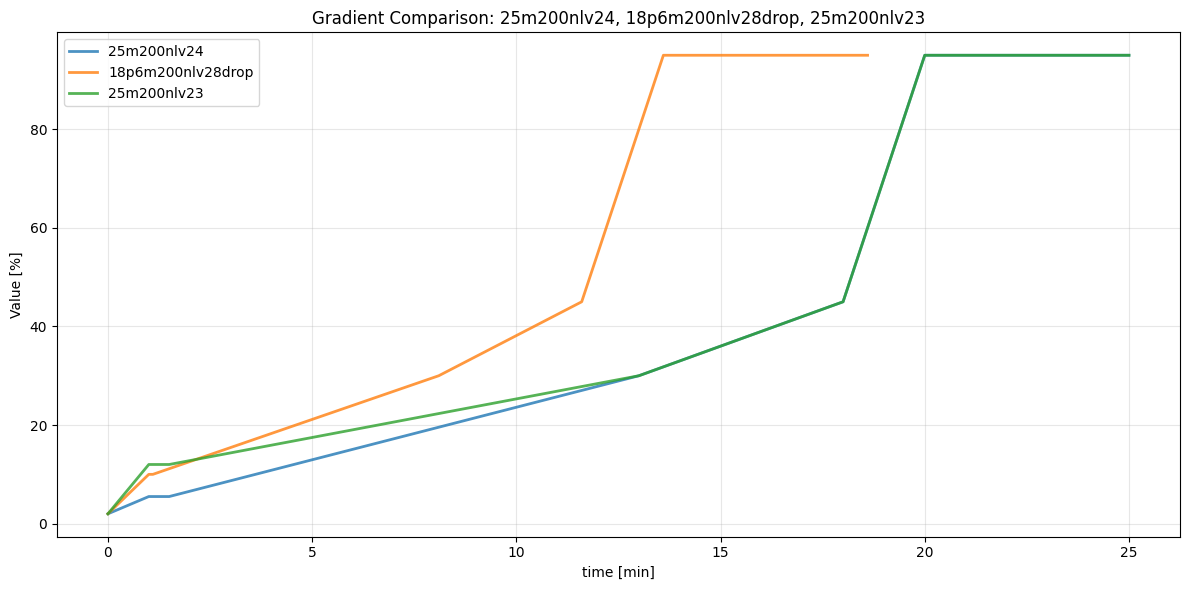

In [83]:
lccollection.plot_gradients(['25m200nlv24', '18p6m200nlv28drop', '25m200nlv23'], y_cols = ['Neo.PumpModule.Pump.%B.Value [%]'])

/opt/anaconda3/envs/diann_report_venv/lib/python3.9/site-packages/seaborn/distributions.py:1176: UserWarning: The following kwargs were not used by contour: 's'
  cset = contour_func(


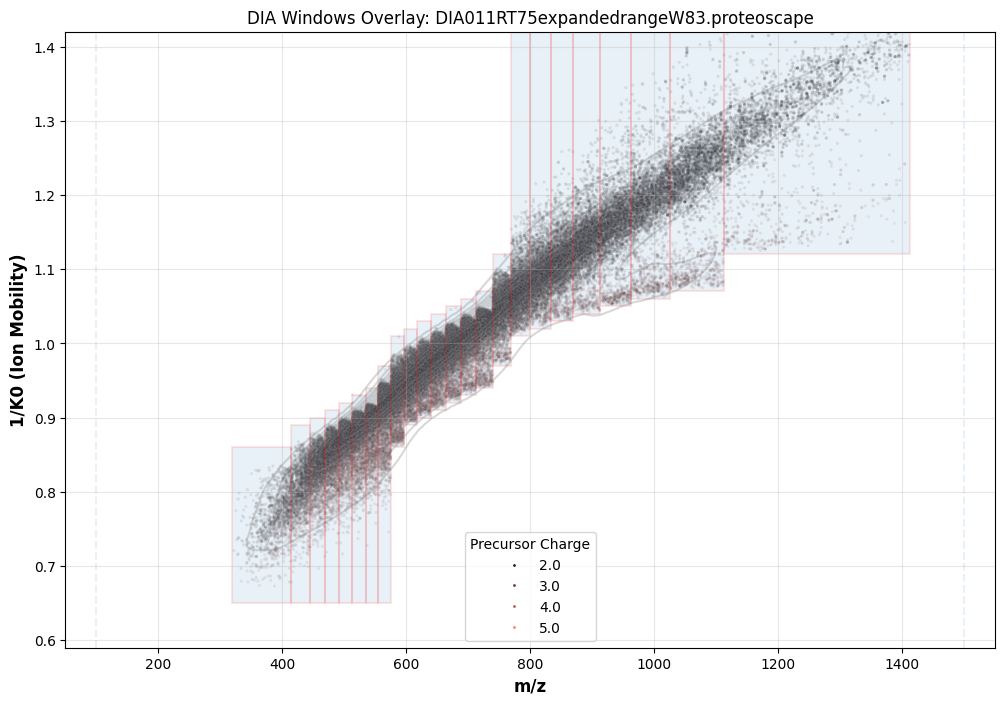

In [ ]:
fig, ax = plt.subplots(figsize=(12, 8))
adata = bpscollection.data['precursor']
sample = adata[:, 'HeLa_20ng_2ACN01TFA_0015DDM_2uL_VNeo_Aurora15_16_17p75m150nlv12_DIA75msW83_TT0000219_B-B1_1_14620']

# 1. Plot DIA windows first (m/z × IM space)

# Scatter plot of precursors
sns.scatterplot(
    x = sample.layers['Precursor.Calibrated.Mz'][:, 0], 
    y = sample.layers['Exp.1/K0'][:, 0],
    hue = sample.obs['Precursor.Charge'].values,
    palette=sns.color_palette("dark:salmon", as_cmap=True),
    s=5, 
    alpha=0.1,
    ax=ax)



mscollection.plot_windows(['DIA011RT75expandedrangeW83.proteoscape'], 
                          color_by_method=True,
                          alpha=0.1,
                          show_labels=False,
                          edge_color ='red',
                          ax=ax)

sns.kdeplot(x = sample.layers['Precursor.Calibrated.Mz'].flatten(), 
           y = sample.layers['Exp.1/K0'].flatten(),
           s=1, 
           alpha=0.3, 
           color='grey',
           ax=ax)

ax.legend(title='Precursor Charge')

legend = ax.legend_
for lh in legend.legend_handles:
    lh.set_alpha(1) # Set alpha to 1 (fully opaque)
    lh._sizes = [250]

# plt.tight_layout()


#### Ion Mobility Errir

(-0.2, 0.2)

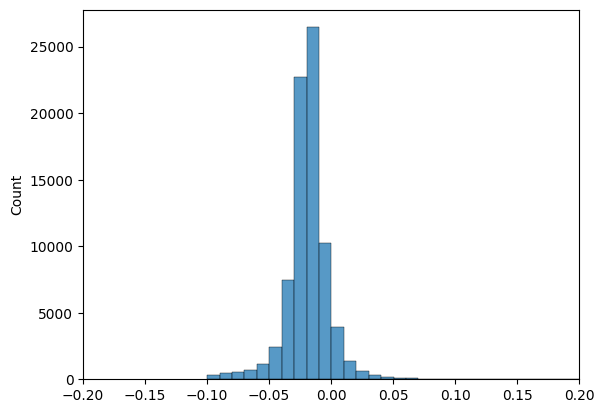

In [66]:
sns.histplot((sample.layers['Lib.1/K0'] - sample.layers['Exp.1/K0']).flatten(), binwidth =0.01)
plt.xlim(-0.2, 0.2)

/opt/anaconda3/envs/diann_report_venv/lib/python3.9/site-packages/seaborn/distributions.py:1176: UserWarning: The following kwargs were not used by contour: 's'
  cset = contour_func(


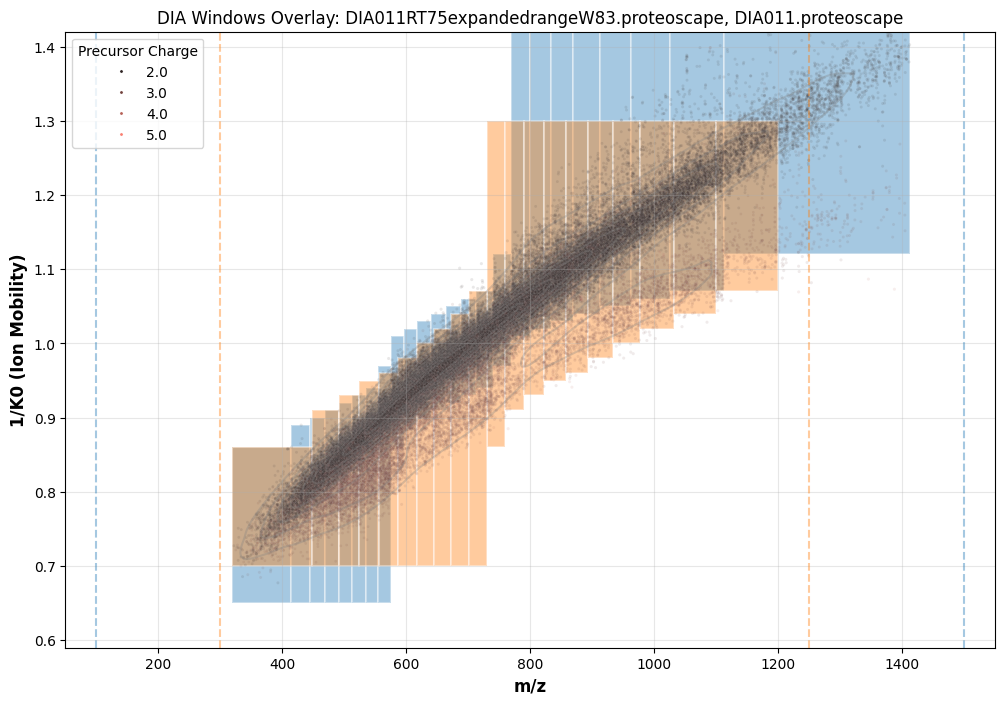

In [ ]:
fig, ax = plt.subplots(figsize=(12, 8))
adata = samplecollection.data['precursor']
sample = adata[:, 'HeLa_20ng_2ACN01TFA_0015DDM_2uL_VNeo_Aurora15_16_17p75m150nlv12_DIA75msW83_TT0000219_B-B1_1_14620']

# 1. Plot DIA windows first (m/z × IM space)
sns.kdeplot(x = sample.layers['Precursor.Calibrated.Mz'].flatten(), 
           y = sample.layers['Lib.1/K0'].flatten(),
           s=1, 
           alpha=0.3, 
           color='grey',
           ax=ax)

mscollection.plot_windows(['DIA011RT75expandedrangeW83.proteoscape', 'DIA011.proteoscape'], 
                          color_by_method=True,
                          alpha=0.4,
                          show_labels=False, 
                          ax=ax)

# Scatter plot of precursors
sns.scatterplot(
    x = sample.layers['Precursor.Calibrated.Mz'][:, 0], 
    y = sample.layers['Lib.1/K0'][:, 0],
    hue = sample.obs['Precursor.Charge'].values,
    palette=sns.color_palette("dark:salmon", as_cmap=True),
    s=5, 
    alpha=0.1,
    ax=ax)

ax.legend(title='Precursor Charge')

legend = ax.legend_
for lh in legend.legend_handles:
    lh.set_alpha(1) # Set alpha to 1 (fully opaque)
    lh._sizes = [250

# plt.tight_layout()


## Matching Methods to Samples

In [ ]:
df = pd.read_csv('/Users/eileen.wang/Desktop/diann/SampleData/Sequences/2026_01_lcmsmethodmapping.csv')

In [204]:
def plot_precursor_mz_im(adata, s, mscollection, ms_method='sample', mz ='Precursor.Calibrated.Mz', im='Exp.1/K0'):
    fig, ax = plt.subplots(figsize=(12, 8))
    
    sample = adata[:, s]

    # 1. Plot DIA windows first (m/z × IM space)
    sns.kdeplot(x = sample.layers[mz].flatten(), 
            y = sample.layers[im].flatten(),
            s=1, 
            alpha=0.3, 
            color='grey',
            ax=ax)

    if ms_method == 'sample':
        meth = adata.var.loc[s, 'MSmeth']
        mscollection.plot_windows([meth], 
                                color_by_method=True,
                                alpha=0.4,
                                show_labels=False, 
                                ax=ax)

    # Scatter plot of precursors
    sns.scatterplot(
        x = sample.layers[mz][:, 0], 
        y = sample.layers[im][:, 0],
        hue = sample.obs['Precursor.Charge'].values,
        palette=sns.color_palette("dark:salmon", as_cmap=True),
        s=5, 
        alpha=0.1,
        ax=ax)

    ax.legend(title='Precursor Charge')

    legend = ax.legend_
    for lh in legend.legend_handles:
        lh.set_alpha(1) # Set alpha to 1 (fully opaque)
        lh._sizes = [250]

    # plt.tight_layout()


/opt/anaconda3/envs/diann_report_venv/lib/python3.9/site-packages/seaborn/distributions.py:1176: UserWarning: The following kwargs were not used by contour: 's'
  cset = contour_func(


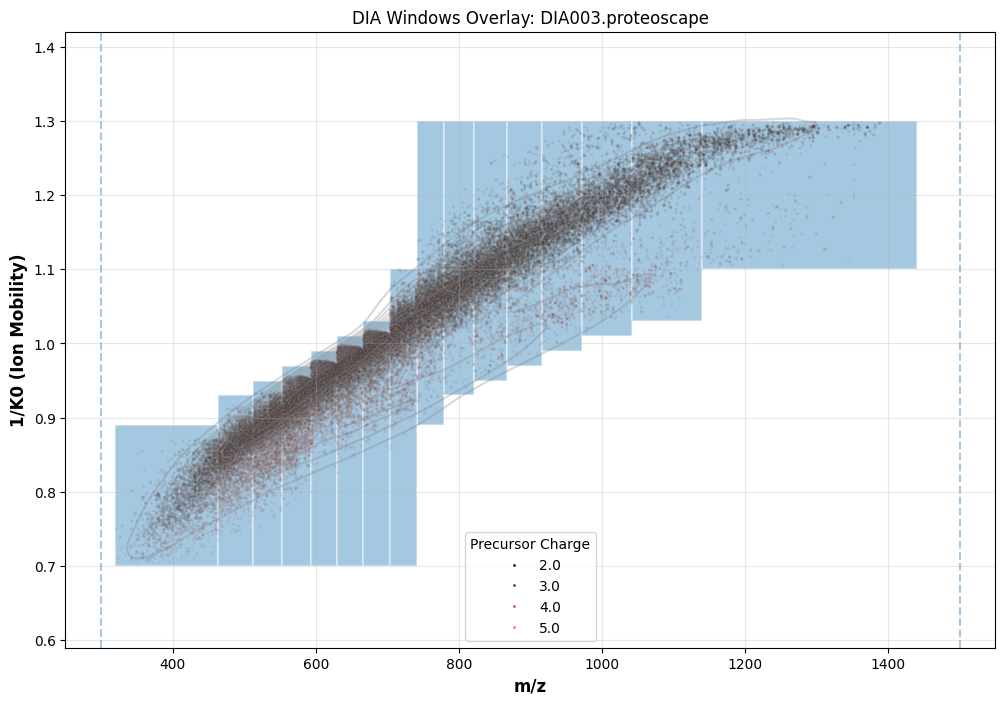

In [241]:
plot_precursor_mz_im(test, 'HeLa_20ng_2ACN01TFA_0015DDM_2uL_VNeo_Aurora15_16_20min_DIA003_TT0000182_B-B11_1_14584', mscollection)

# Analyzing Methods

1. How many precursors are being collected/detected per cycle?
2. How many precusors are being collected per unit time?
3. What percentage of precursors do our DIA windows collect?
   * Which precursors does it leave out?
   * Evaluating window size vs precursors actually in a window per unit time? 
4. What is the difference in number of precursors detected per sample/run?
   * How do they plot in terms of RT, IM, MZ, etc
5. Carryover?
   * % of total intensity 
   * % vs intensity in previous sample
   * properties of carrover/distribution vs RT